# 03 Product Category Analysis

## Project Objectives

- Identify high-performing and low-performing product categories
- Analyse category sales, satisfaction, and customer preference
- Support category operation and inventory decisions with data evidence

## 1. Data Loading & Initial Exploration

In [ ]:
# Import library code units
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.unicode_minus"] = False

### 1.1 Category-level Data Loading

To analyse product category performance, the first step is to load a category-level aggregated dataset from the MySQL data warehouse. This table summarises the key business indicators for each product category, including sales volume, customer count, revenue, freight cost, review score, bad review rate, repurchase proxy, and category lifecycle. Since the data is already aggregated at the category level, each row represents one product category rather than one individual order or one customer.

In [3]:
# load category-level aggregated data from MySQL
# each row in this dataset represents one product category
from src.utils.db import get_engine

engine = get_engine()

sql_category = """
SELECT *
FROM view_category_analysis
"""

df_category = pd.read_sql(sql_category, engine)

print(df_category.shape)
df_category.head()

(73, 14)


,category,order_count,customer_count,total_revenue,total_gmv,avg_price,avg_freight,avg_review_score,bad_review_rate,avg_comment_len,repeat_rate,first_sale_date,last_sale_date,category_lifetime_days
0,agro_industria_e_comercio,182,182,72530.47,78374.07,342.124858,27.564151,4.0000,16.03774,20.7028,1.0,2017-01-23 07:03:04,2018-08-26 07:57:32,580
1,alimentos,450,450,29393.41,36664.44,57.634137,14.256922,4.2134,13.00813,22.6199,1.0,2016-10-10 11:22:36,2018-08-29 11:06:11,688
2,alimentos_bebidas,227,227,15218.47,19753.64,54.546487,16.255090,4.3091,8.00000,20.7891,1.0,2017-03-05 01:03:51,2018-08-23 19:57:47,536
3,artes,202,202,24202.64,28247.81,115.802105,19.354880,3.9515,17.96117,31.5777,1.0,2017-03-01 10:56:53,2018-08-27 19:37:48,544
4,artes_e_artesanato,23,23,1814.01,2184.14,75.583750,15.422083,4.1250,12.50000,43.4167,1.0,2017-05-08 12:01:54,2018-08-24 12:41:33,473


In [4]:
# View the fields and data types of the df_category table.
df_category.info()

<class 'pandas.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   category                73 non-null     str           
 1   order_count             73 non-null     int64         
 2   customer_count          73 non-null     int64         
 3   total_revenue           73 non-null     float64       
 4   total_gmv               73 non-null     float64       
 5   avg_price               73 non-null     float64       
 6   avg_freight             73 non-null     float64       
 7   avg_review_score        73 non-null     float64       
 8   bad_review_rate         73 non-null     float64       
 9   avg_comment_len         73 non-null     float64       
 10  repeat_rate             73 non-null     float64       
 11  first_sale_date         73 non-null     datetime64[us]
 12  last_sale_date          73 non-null     datetime64[us]
 13  cat

In [5]:
df_category.columns.tolist()

['category',
 'order_count',
 'customer_count',
 'total_revenue',
 'total_gmv',
 'avg_price',
 'avg_freight',
 'avg_review_score',
 'bad_review_rate',
 'avg_comment_len',
 'repeat_rate',
 'first_sale_date',
 'last_sale_date',
 'category_lifetime_days']

In [6]:
df_category["category"].nunique()

73

The category-level dataset contains aggregated information for 73 product categories and 14 variables. This confirms that the table is structured at the category level rather than the transaction level. Such a dataset is suitable for high-level comparative analysis across categories, such as ranking categories by revenue, identifying high- and low-performing groups, and constructing category strategy frameworks such as Pareto analysis and quadrant classification.

### 1.2 Order-level Data Loading
In addition to the category-level aggregated table, this project also requires a more detailed order-level dataset. The category-level table is useful for overall comparison, but it does not preserve transaction-level variation. To analyse pricing patterns, customer preference, delivery-related variables, satisfaction behaviour, and temporal trends, an order-item level dataset is loaded by joining product, order, review, and customer information from the warehouse.

In [7]:
# load order_item level data for detailed category analysis
# each row in this dataset represents an order item linked to a category
sql_orders = """
SELECT
    p.category,
    oi.order_id,
    o.user_id,
    oi.product_id,
    oi.price,
    oi.freight_value,
    oi.gmv,
    o.purchase_ts,
    o.delivered_days,
    r.review_score,
    r.review_comment_len,
    u.state AS customer_state
FROM fact_order_item oi
JOIN dim_product p
    ON oi.product_id = p.product_id
JOIN fact_order o
    ON oi.order_id = o.order_id
LEFT JOIN fact_review r
    ON o.order_id = r.order_id
LEFT JOIN dim_user u
    ON o.user_id = u.user_id
WHERE p.category IS NOT NULL
"""

# read sql result into pandas dataframe
df_orders = pd.read_sql(sql_orders, engine)

# check dataset shape
print(df_orders.shape)

# preview the first few rows
df_orders.head()

(111426, 12)


,category,order_id,user_id,product_id,price,freight_value,gmv,purchase_ts,delivered_days,review_score,review_comment_len,customer_state
0,cool_stuff,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,4244733e06e7ecb4970a6e2683c13e61,58.90,13.29,72.19,2017-09-13 08:59:02,7.0,5.0,46.0,RJ
1,pet_shop,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,e5f2d52b802189ee658865ca93d83a8f,239.90,19.93,259.83,2017-04-26 10:53:06,16.0,4.0,0.0,SP
2,moveis_decoracao,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,c777355d18b72b67abbeef9df44fd0fd,199.00,17.87,216.87,2018-01-14 14:33:31,8.0,5.0,90.0,MG
3,perfumaria,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,7634da152a4610f1595efa32f14722fc,12.99,12.79,25.78,2018-08-08 10:00:35,6.0,4.0,0.0,SP
4,ferramentas_jardim,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,ac6c3623068f30de03045865e4e10089,199.90,18.14,218.04,2017-02-04 13:57:51,25.0,5.0,39.0,SP


The order-level dataset preserves detailed transaction records and is much larger than the aggregated category-level dataset. Each row corresponds to an order item associated with a product category, customer, and review context. This dataset is necessary for downstream analyses that cannot be carried out at the grouped category level, including price distribution analysis, category preference by user segment, monthly sales trend analysis, state-level category comparison, and selected statistical tests.

### 1.3 Data Structure Check
Before starting the formal analysis, it is necessary to check the structure and data quality of the two datasets. This includes examining variable types, identifying data fields, and check whether important variables contain missing values. These checks help ensure that the following analysis is based on correctly formatted and reliable data.

In [8]:
# check the structure, data types, and non-null counts of both datasets

print("Category-level dataset info:")
df_category.info()

print("\n" + "=" * 60 + "\n")

print("Order-level dataset info:")
df_orders.info()

Category-level dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   category                73 non-null     str           
 1   order_count             73 non-null     int64         
 2   customer_count          73 non-null     int64         
 3   total_revenue           73 non-null     float64       
 4   total_gmv               73 non-null     float64       
 5   avg_price               73 non-null     float64       
 6   avg_freight             73 non-null     float64       
 7   avg_review_score        73 non-null     float64       
 8   bad_review_rate         73 non-null     float64       
 9   avg_comment_len         73 non-null     float64       
 10  repeat_rate             73 non-null     float64       
 11  first_sale_date         73 non-null     datetime64[us]
 12  last_sale_date          73 non-nul

In [9]:
# check missing values in both datasets

print("Missing values in df_category:")
print(df_category.isnull().sum())

print("\n" + "=" * 60 + "\n")

print("Missing values in df_orders:")
print(df_orders.isnull().sum())

Missing values in df_category:
category                  0
order_count               0
customer_count            0
total_revenue             0
total_gmv                 0
avg_price                 0
avg_freight               0
avg_review_score          0
bad_review_rate           0
avg_comment_len           0
repeat_rate               0
first_sale_date           0
last_sale_date            0
category_lifetime_days    0
dtype: int64


Missing values in df_orders:
category                 0
order_id                 0
user_id                  0
product_id               0
price                    0
freight_value            0
gmv                      0
purchase_ts              0
delivered_days        2399
review_score          1572
review_comment_len    1572
customer_state           0
dtype: int64


### Data Structure Check analysis and summary
The data structure check shows that the category-level dataset is clean, compact, and already well aggregated. It contains 73 product categories and 14 variables, including sales indicators, customer-related metrics, review-related measures, and lifecycle information. No missing values are found in this dataset, and both `first_sale_date` and `last_sale_date` have already been correctly recognised as datetime variables. This means the category-level table is ready for direct use in category comparison, ranking analysis, Pareto analysis, and quadrant-based strategic classification.

The order-level dataset contains 111,426 transaction records and 12 variables, which provide a much more detailed view of category behaviour. Most key business fields, including category, order ID, user ID, product ID, price, freight value, GMV, purchase timestamp, and customer state, are complete. The `purchase_ts` field has also been correctly stored as a datetime variable, which is suitable for later time-series analysis.

However, some missing values are present in the order-level dataset. Specifically, `delivered_days` contains 2,399 missing values, while `review_score` and `review_comment_len` each contain 1,572 missing values. These missing values are expected in an e-commerce context. Missing delivery information usually corresponds to orders that were not fully delivered or whose delivery status was incomplete at the time of data recording. Missing review-related values are also common because not all customers leave a review after purchase. Therefore, these missing values should not be removed blindly from the full dataset. Instead, they should be handled selectively depending on the analytical objective of each later section.

### 1.4 Data Preparation
Before moving to exploratory analysis, a small amount of data preparation is carried out. Since the full order-level dataset will support multiple downstream tasks, it is useful to prepare separate subsets for review-related analysis and delivery-related analysis.This avoids unnecessary global data deletion and keeps the original transaction dataset intact for later use.

In [10]:
# create analysis-specific subsets from the full order-level dataset
# keep the original df_orders unchanged

# subset for review-related analysis
df_review = df_orders[df_orders["review_score"].notna()].copy()

# subset for delivery-related analysis
df_delivery = df_orders[df_orders["delivered_days"].notna()].copy()

# subset for analysis requiring both review and delivery information
df_review_delivery = df_orders[
    df_orders["review_score"].notna() &
    df_orders["delivered_days"].notna()
].copy()

# check the size of each subset
print("Full order-level dataset:", df_orders.shape)
print("Review subset:", df_review.shape)
print("Delivery subset:", df_delivery.shape)
print("Review + Delivery subset:", df_review_delivery.shape)

Full order-level dataset: (111426, 12)
Review subset: (109854, 12)
Delivery subset: (109027, 12)
Review + Delivery subset: (107587, 12)


Instead of removing missing values from the full order-level dataset, task-specific subsets were created for later analysis. The full order-level dataset contains 111,426 records. Among them, 109,854 records have valid review information, 109,027 records have valid delivery duration information, and 107,587 records contain both review and delivery information. This result shows that the proportion of missing values is relatively small compared with the full dataset. Therefore, using separate subsets is a suitable strategy because it preserves the full transaction table for general category analysis while allowing more focused analysis when review or delivery variables are required.

## 2. Exploratory Data Analysis
Exploratory data analysis is carried out to understand the structure, distribution, and reliability of the category-level and order-level datasets before moving to business interpretation. This stage focuses on missing values, variable distributions, which help identify potential data issues and provide cntext for later comparative analysis.

### 2.1 Missing Value Summary and Interpretation
The first step in exploratory analysis is to review missing values in both datasets. Missing-value patterns are important because they affect which records can be used in later analysis, especially for review-related and delivery-related variables.

In [11]:
# summarise missing values in both datasets

missing_category = pd.DataFrame({
    "missing_count": df_category.isnull().sum(),
    "missing_pct": df_category.isnull().mean() * 100
})

missing_orders = pd.DataFrame({
    "missing_count": df_orders.isnull().sum(),
    "missing_pct": df_orders.isnull().mean() * 100
})

print("Missing values in category-level dataset:")
display(missing_category[missing_category["missing_count"] > 0])

print("\nMissing values in order-level dataset:")
display(missing_orders[missing_orders["missing_count"] > 0].sort_values("missing_count", ascending=False))

Missing values in category-level dataset:


,missing_count,missing_pct



Missing values in order-level dataset:


,missing_count,missing_pct
delivered_days,2399,2.152998
review_score,1572,1.410802
review_comment_len,1572,1.410802


### 2.1 Missing Value Summary and Interpretation — revised analysis text

The missing-value summary confirms that the category-level dataset is fully complete, with no missing values across all 14 variables. This means the aggregated table can be used directly for category ranking, quadrant classification, correlation analysis, and other category-level comparisons without additional cleaning.

By contrast, the order-level dataset contains a small proportion of missing values in three variables: delivered_days, review_score, and review_comment_len. The missing rate is low overall, with about 2.15% missing in delivery duration and about 1.41% missing in review-related fields. These missing values are structurally understandable in an e-commerce context, since not all orders are fully delivered and not all customers leave reviews.

Because the proportion of missing values is relatively small and the missingness is concentrated in specific behavioural variables rather than the core transaction fields, it is more appropriate to keep the full dataset unchanged and use task-specific subsets for downstream analysis. This preserves as much information as possible while ensuring that later review-based or delivery-based analyses remain valid.

### 2.2 Category-level Numerical Distribution Analysis
To understand how product categories differ from one another, the next step is to examine the distribution of the main category-level indicators. This helps reveal whether category performance is evenly distributed or dominated by a small number of high-performing categories. It also provides context for later ranking analysis, Pareto analysis, and BCG-style classification.

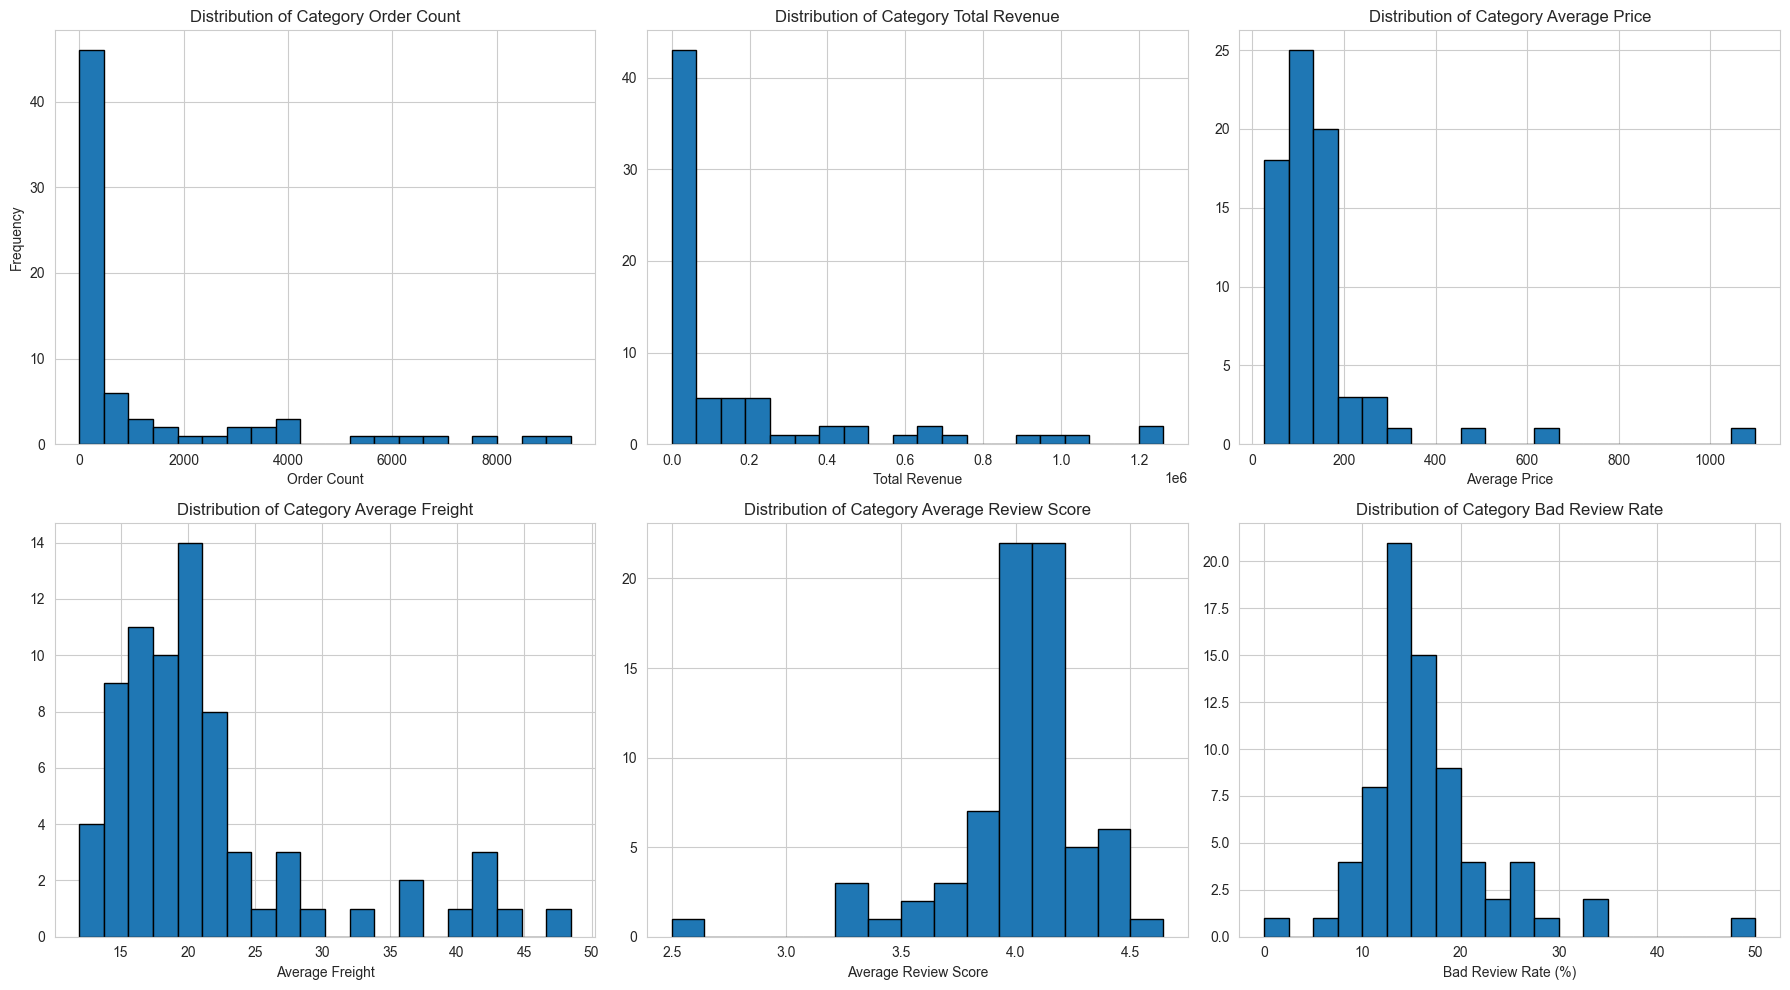

In [12]:
# plot the distribution of major category-level metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# order count
axes[0, 0].hist(df_category["order_count"], bins=20, edgecolor="black")
axes[0, 0].set_title("Distribution of Category Order Count")
axes[0, 0].set_xlabel("Order Count")
axes[0, 0].set_ylabel("Frequency")

# total revenue
axes[0, 1].hist(df_category["total_revenue"], bins=20, edgecolor="black")
axes[0, 1].set_title("Distribution of Category Total Revenue")
axes[0, 1].set_xlabel("Total Revenue")

# average price
axes[0, 2].hist(df_category["avg_price"], bins=20, edgecolor="black")
axes[0, 2].set_title("Distribution of Category Average Price")
axes[0, 2].set_xlabel("Average Price")

# average freight
axes[1, 0].hist(df_category["avg_freight"], bins=20, edgecolor="black")
axes[1, 0].set_title("Distribution of Category Average Freight")
axes[1, 0].set_xlabel("Average Freight")

# average review score
axes[1, 1].hist(df_category["avg_review_score"], bins=15, edgecolor="black")
axes[1, 1].set_title("Distribution of Category Average Review Score")
axes[1, 1].set_xlabel("Average Review Score")

# bad review rate
axes[1, 2].hist(df_category["bad_review_rate"], bins=20, edgecolor="black")
axes[1, 2].set_title("Distribution of Category Bad Review Rate")
axes[1, 2].set_xlabel("Bad Review Rate (%)")

plt.tight_layout()
plt.show()

### Category-level Numerical Distribution Analysis
The distribution plots show that category performance is highly uneven across product categories. Both `order_count` and `total_revenue` are strongly right-skewed, which means a small number of categories contribute a disproportionately large share of total sales and orders. By contrast, `avg_review_score` is much more concentrated, with most categories clustered around 4.0, suggesting that customer satisfaction is relatively stable across categories. `avg_price`, `avg_freight`, and `bad_review_rate` also show noticeable variation, indicating that categories differ not only in sales scale but also in pricing structure, logistics burden, and review risk.

In [13]:
# summary statistics for key category-level variables

summary_stats = df_category[
    [
        "order_count",
        "customer_count",
        "total_revenue",
        "total_gmv",
        "avg_price",
        "avg_freight",
        "avg_review_score",
        "bad_review_rate",
        "avg_comment_len",
        "repeat_rate",
        "category_lifetime_days",
    ]
].describe().T

summary_stats

,count,mean,std,min,25%,50%,75%,max
order_count,73.0,1342.726027,2252.345988,2.000000,75.000000,244.000000,1273.000000,9.417000e+03
customer_count,73.0,1342.726027,2252.345988,2.000000,75.000000,244.000000,1273.000000,9.417000e+03
total_revenue,73.0,184193.989726,301910.559304,283.290000,7528.410000,46328.370000,191498.880000,1.261035e+06
total_gmv,73.0,214750.303288,349566.278958,324.510000,8754.610000,50193.570000,210137.370000,1.444124e+06
avg_price,73.0,146.695252,146.105578,25.342333,81.801667,114.949474,154.407282,1.098341e+03
avg_freight,73.0,21.620984,8.198948,11.938750,16.255090,19.324810,22.724680,4.845468e+01
avg_review_score,73.0,4.019816,0.313812,2.500000,3.936500,4.056200,4.170000,4.642900e+00
bad_review_rate,73.0,16.405375,6.885987,0.000000,12.978280,15.068490,18.000000,5.000000e+01
avg_comment_len,73.0,30.527571,13.073281,4.125000,26.740700,29.305600,32.806700,1.150000e+02
repeat_rate,73.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00


### summary statistics analysis
The descriptive statistics further confirm that category performance is highly dispersed. For example, the median `order_count` is only 244, while the mean is much higher at about 1342.73, showing that a few very large categories pull the average upward. A similar pattern appears in `total_revenue`, where the mean is far above the median, again indicating strong concentration among top-performing categories. In contrast, `avg_review_score` has a narrow spread around 4.02, suggesting that satisfaction differences exist but are much smaller than sales differences. It is also worth noting that `repeat_rate` is constant at 1.0 for all categories, which means this variable has no variation in the current aggregated table and may have limited analytical value in later sections.

### 2.3 Outlier Detection for Key Category Metrics
Because category-level business indicators may be dominated by a few extremely large or small categories, it is useful to check whether outliers are present. Outlier detection helps distinguish between normal variation and unusually extreme category behaviour. In this project, the IQR rule is used as a simple and interpretable method for identifying extreme values.

In [14]:
# function to detect outliers using IQR
def detect_outliers_iqr(df, columns):
    results = []

    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)

        results.append({
            "variable": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_mask.sum(),
            "outlier_pct": outlier_mask.mean() * 100
        })

    return pd.DataFrame(results)

key_vars = ["order_count", "total_revenue", "avg_price", "avg_freight", "bad_review_rate"]

outlier_summary = detect_outliers_iqr(df_category, key_vars)
outlier_summary

,variable,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,order_count,75.000000,1273.000000,1198.000000,-1722.000000,3070.000000,13,17.808219
1,total_revenue,7528.410000,191498.880000,183970.470000,-268427.295000,467454.585000,11,15.068493
2,avg_price,81.801667,154.407282,72.605615,-27.106756,263.315705,7,9.589041
3,avg_freight,16.255090,22.724680,6.469590,6.550705,32.429065,9,12.328767
4,bad_review_rate,12.978280,18.000000,5.021720,5.445700,25.532580,9,12.328767


### IQR analysis
The IQR-based outlier summary shows that extreme values are most visible in `order_count` and `total_revenue`, where 13 and 11 categories are flagged as outliers respectively. This suggests that category sales structure is strongly dominated by a relatively small group of very large categories. Outliers are also present in `avg_price`, `avg_freight`, and `bad_review_rate`, although to a lesser extent, indicating that some categories are unusually expensive, costly to deliver, or associated with unusually high negative feedback. These results suggest that outliers in this project are not random noise, but potentially meaningful business signals.

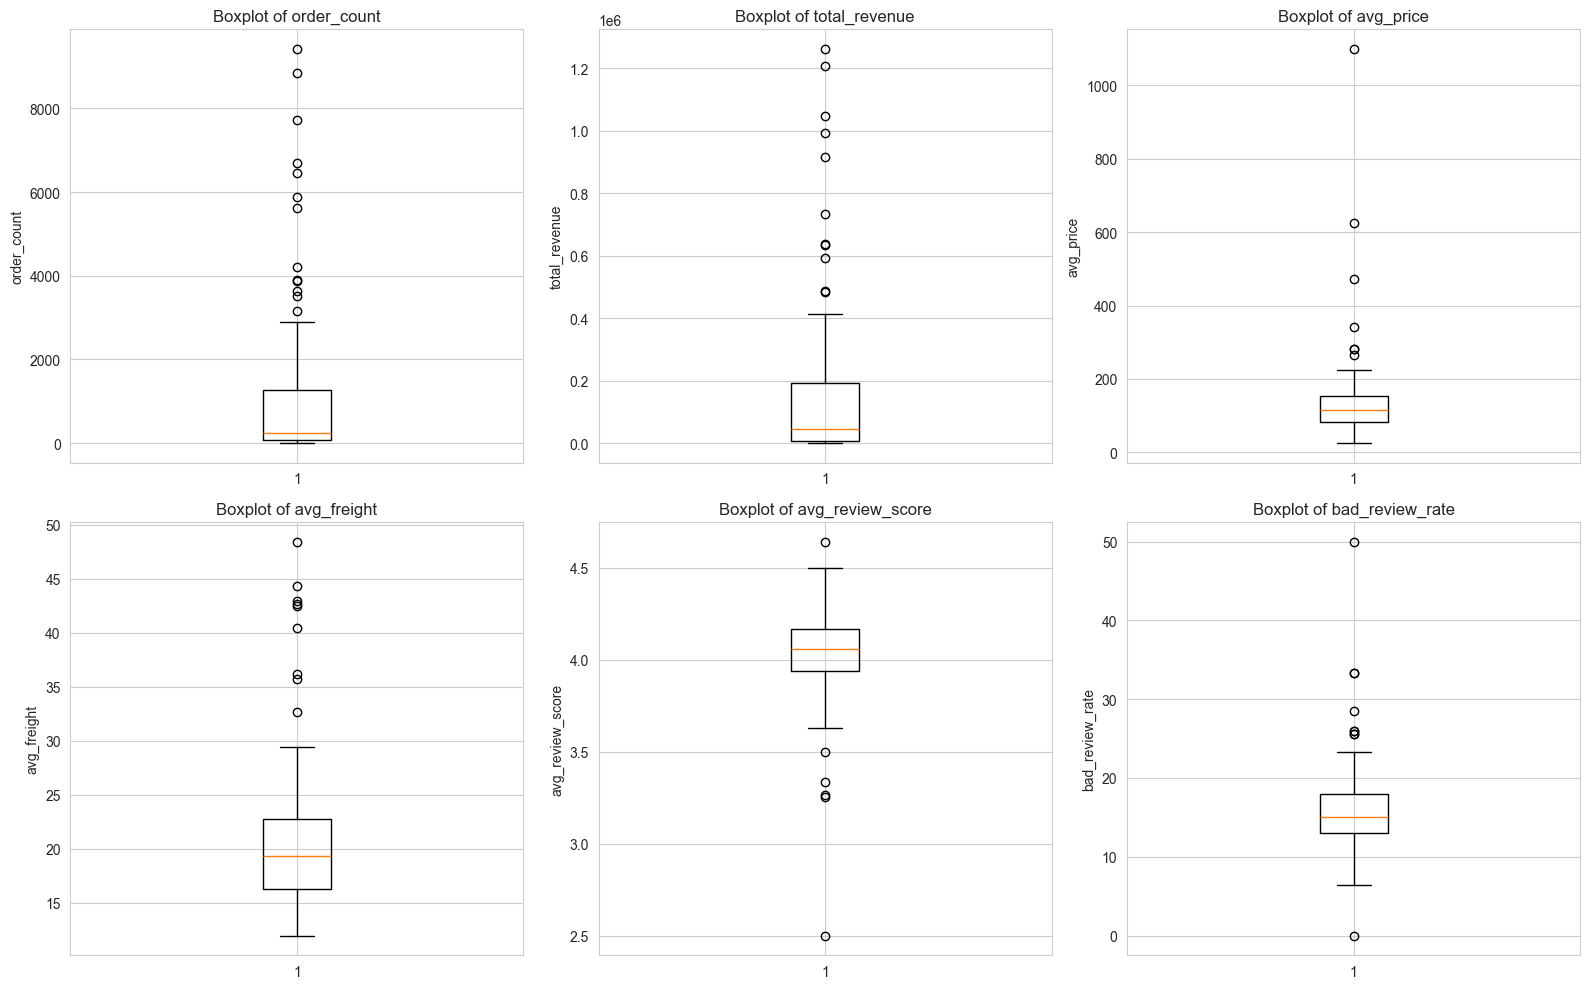

In [15]:
# boxplots for selected category-level variables

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_vars = ["order_count", "total_revenue", "avg_price", "avg_freight", "avg_review_score", "bad_review_rate"]

for i, col in enumerate(plot_vars):
    axes[i].boxplot(df_category[col].dropna(), vert=True)
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### boxplots for selected category-level variables analysis
The boxplots provide a visual confirmation of the outlier patterns identified above. `order_count` and `total_revenue` show long upper tails and many points above the upper whisker, which indicates that several categories perform far above the typical range. `avg_price` and `avg_freight` also contain a number of high-end outliers, suggesting that some product groups operate in clearly different price and logistics bands. Meanwhile, `avg_review_score` is much more tightly distributed, although a few low-score categories stand out and many deserve closer business attention. The `bad_review_rate` boxplot also reveals several high-risk categories with unusually poor review outcomes.

In [16]:
# identify the specific categories flagged as outliers for selected variables

for col in ["order_count", "total_revenue", "avg_price", "bad_review_rate"]:
    q1 = df_category[col].quantile(0.25)
    q3 = df_category[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df_category[
        (df_category[col] < lower_bound) | (df_category[col] > upper_bound)
    ][["category", col]].sort_values(col, ascending=False)

    print(f"\nOutlier categories for {col}:")
    display(outliers)


Outlier categories for order_count:


,category,order_count
13,cama_mesa_banho,9417
11,beleza_saude,8836
32,esporte_lazer,7720
44,informatica_acessorios,6689
54,moveis_decoracao,6449
72,utilidades_domesticas,5884
66,relogios_presentes,5624
70,telefonia,4199
8,automotivo,3897
12,brinquedos,3886



Outlier categories for total_revenue:


,category,total_revenue
11,beleza_saude,1261034.70
66,relogios_presentes,1206047.43
13,cama_mesa_banho,1045462.93
32,esporte_lazer,991175.20
44,informatica_acessorios,916137.43
54,moveis_decoracao,733077.86
26,cool_stuff,636254.61
72,utilidades_domesticas,632981.59
8,automotivo,593227.66
40,ferramentas_jardim,486400.55



Outlier categories for avg_price:


,category,avg_price
61,pcs,1098.340542
64,portateis_casa_forno_e_cafe,624.285658
29,eletrodomesticos_2,473.272458
0,agro_industria_e_comercio,342.124858
45,instrumentos_musicais,281.616000
31,eletroportateis,280.284112
65,portateis_cozinha_e_preparadores_de_alimentos,264.568667



Outlier categories for bad_review_rate:


,category,bad_review_rate
67,seguros_e_servicos,50.00000
65,portateis_cozinha_e_preparadores_de_alimentos,33.33333
60,pc_gamer,33.33333
38,fashion_roupa_masculina,28.46154
15,casa_conforto_2,25.92593
55,moveis_escritorio,25.92372
42,fraldas_higiene,25.64103
71,telefonia_fixa,25.57252
17,cds_dvds_musicais,0.00000


### The category-level outlier tables analysis
The category-level outlier tables show that the extreme observations are concentrated in a few specific product groups. In terms of sales scale, categories such as `cama_mesa_banho`, `beleza_saude`, `esporte_lazer`, `informatica_acessorios`, and `moveis_decoracao` stand out as major outliers in both `order_count` and `total_revenue`, which suggests that they function as core commercial categories in the platform. In terms of pricing, categories such as `pcs`, `portateis_casa_forno_e_cafe`, and `eletrodomesticos_2` have exceptionally high average prices, indicating that they belong to premium or specialised product segments rather than mass-market categories. In contrast, categories such as `seguros_e_servicos`, `pc_gamer`, and `fashion_roupa_masculina` appear as outliers in `bad_review_rate`, suggesting potential issues in customer expectation, product quality, or service performance. Overall, these outlier categories should not be treated as data errors; instead, they represent strategically important groups that deserve closer examination in the later ranking and business insight sections.

### 2.4 Preliminary Revenue Concentration Check
Before moving to formal ranking analysis, it is useful to briefly examine how concentrated category revenue is. This provides an early indication of whether the category structure is broad-based or heavily dependent on a small number of categories.

In [17]:
# calculate category revenue share
df_concentration = df_category[["category", "total_revenue"]].copy()
df_concentration["revenue_share_pct"] = (
    df_concentration["total_revenue"] / df_concentration["total_revenue"].sum() * 100
)

df_concentration = df_concentration.sort_values("total_revenue", ascending=False)

print("Top 10 categories by revenue share:")
display(df_concentration.head(10))

print(f"Revenue share of top 5 categories: {df_concentration.head(5)['revenue_share_pct'].sum():.2f}%")
print(f"Revenue share of top 10 categories: {df_concentration.head(10)['revenue_share_pct'].sum():.2f}%")

Top 10 categories by revenue share:


,category,total_revenue,revenue_share_pct
11,beleza_saude,1261034.70,9.378399
66,relogios_presentes,1206047.43,8.969455
13,cama_mesa_banho,1045462.93,7.775178
32,esporte_lazer,991175.20,7.371436
44,informatica_acessorios,916137.43,6.813375
54,moveis_decoracao,733077.86,5.451949
26,cool_stuff,636254.61,4.731868
72,utilidades_domesticas,632981.59,4.707526
8,automotivo,593227.66,4.411874
40,ferramentas_jardim,486400.55,3.617393


Revenue share of top 5 categories: 40.31%
Revenue share of top 10 categories: 63.23%


### Top 10 categories by revenue share analysis
The preliminary revenue concentration results show that category sales are highly concentrated among a small number of leading categories. `beleza_saude` ranks first, contributing about 9.38% of total revenue alone, followed by `relogios_presentes` at 8.97% and `cama_mesa_banho` at 7.78%. More importantly, the top 5 categories together account for 40.31% of total revenue, while the top 10 categories contribute 63.23%. This indicates that the platform’s category revenue structure is strongly dependent on a relatively limited set of core categories, which is an important business signal for later Pareto analysis and category strategy planning.

## 3. Category Ranking Analysis
Category ranking analysis aims to identify the best-performing and worst-performing product categories from multiple business perspectives. Instead of looking at only one metric, this chapter compares categories by revenue, order volume, customer satisfaction, and bad review rate. This helps distinguish categories that are commercially important from those that many require operational attention. Such ranking analysis also provides the basis for later Parato analysis and BCG-style strategic classification.

### 3.1 Top 10 Categories by Revenue analysis
Revenue is one of the most direct indicators of category business value. Analysing the top categories by total revenue helps identify which product groups contribute most strongly to platform income. These categories are commercially important because they often represent the main drivers of gross merchandise performance and should therefore receive closer attention in later strategic analysis.

In [18]:
# rank categories by total revenue

top10_revenue = (
    df_category[["category", "total_revenue", "order_count", "avg_review_score"]]
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

print("Top 10 categories by total revenue")
display(top10_revenue)

Top 10 categories by total revenue


,category,total_revenue,order_count,avg_review_score
11,beleza_saude,1261034.70,8836,4.1422
66,relogios_presentes,1206047.43,5624,4.0192
13,cama_mesa_banho,1045462.93,9417,3.9022
32,esporte_lazer,991175.20,7720,4.1087
44,informatica_acessorios,916137.43,6689,3.9364
54,moveis_decoracao,733077.86,6449,3.9114
26,cool_stuff,636254.61,3632,4.1480
72,utilidades_domesticas,632981.59,5884,4.0562
8,automotivo,593227.66,3897,4.0650
40,ferramentas_jardim,486400.55,3518,4.0435


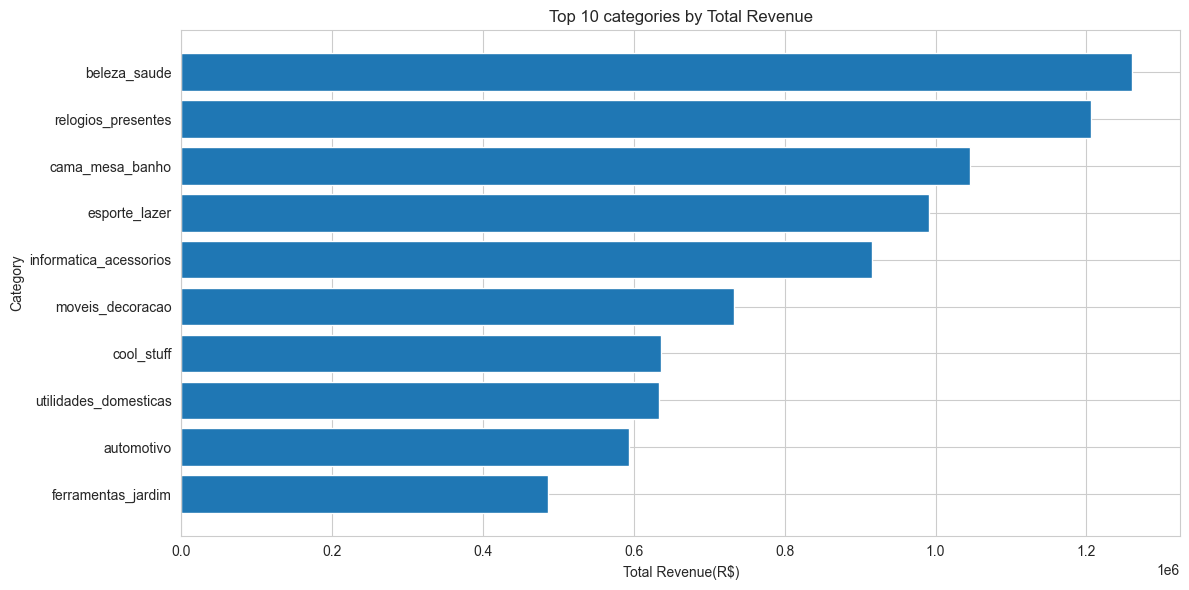

In [19]:
# visualise top 10 categories by total revenue

plt.figure(figsize=(12, 6))
plt.barh(top10_revenue["category"], top10_revenue["total_revenue"])
plt.xlabel("Total Revenue(R$)")
plt.ylabel("Category")
plt.title("Top 10 categories by Total Revenue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
# add revenue share for easier interpretation

top10_revenue = top10_revenue.copy()
top10_revenue["revenue_share_pct"] = (
    top10_revenue["total_revenue"] / df_category["total_revenue"].sum() * 100
)

display(top10_revenue)

,category,total_revenue,order_count,avg_review_score,revenue_share_pct
11,beleza_saude,1261034.70,8836,4.1422,9.378399
66,relogios_presentes,1206047.43,5624,4.0192,8.969455
13,cama_mesa_banho,1045462.93,9417,3.9022,7.775178
32,esporte_lazer,991175.20,7720,4.1087,7.371436
44,informatica_acessorios,916137.43,6689,3.9364,6.813375
54,moveis_decoracao,733077.86,6449,3.9114,5.451949
26,cool_stuff,636254.61,3632,4.1480,4.731868
72,utilidades_domesticas,632981.59,5884,4.0562,4.707526
8,automotivo,593227.66,3897,4.0650,4.411874
40,ferramentas_jardim,486400.55,3518,4.0435,3.617393


### Top 10 Categories by Revenue analysis
The revenue ranking shows that platform income is concentrated in a relatively small group of categories. **beleza_saude** ranks first with total revenue of **R1,261,034.70**, followed by **relogios_presentes** at **R1,206,047.43** and **cama_mesa_banho** at **R1,045,462.93**. Together, these categories form the core revenue drivers of the platform.

Most of the top revenue categories also have high order volumes, such as **beleza_saude**, **cama_mesa_banho**, and **esporte_lazer**, which suggests that their revenue strength is supported by broad market demand rather than only high unit prices. However, some high-revenue categories, including **cama_mesa_banho**, **informatica_acessorios**, and **moveis_decoracao**, have only moderate average review scores. This suggests that strong sales performance does not always correspond to the best customer experience, and these categories deserve further attention in later satisfaction analysis.

### 3.2 Top 10 Categories by Order Count
Order count reflects how frequently a category is purchased and is important indicator of category popularity and market demand. While revenue highlights business value, order volume reveals how broad the demand base is. Analysing the top categories by order count helps identify the most frequently purchased product groups and allow comparison with the revenue ranking above.

In [21]:
# rank categories by order count

top10_orders = (
    df_category[["category", "order_count", "total_revenue", "avg_review_score"]]
    .sort_values("order_count", ascending=False)
    .head(10)
)

print("Top 10 categories by order count")
display(top10_orders)

Top 10 categories by order count


,category,order_count,total_revenue,avg_review_score
13,cama_mesa_banho,9417,1045462.93,3.9022
11,beleza_saude,8836,1261034.70,4.1422
32,esporte_lazer,7720,991175.20,4.1087
44,informatica_acessorios,6689,916137.43,3.9364
54,moveis_decoracao,6449,733077.86,3.9114
72,utilidades_domesticas,5884,632981.59,4.0562
66,relogios_presentes,5624,1206047.43,4.0192
70,telefonia,4199,323735.40,3.9472
8,automotivo,3897,593227.66,4.0650
12,brinquedos,3886,484090.30,4.1617


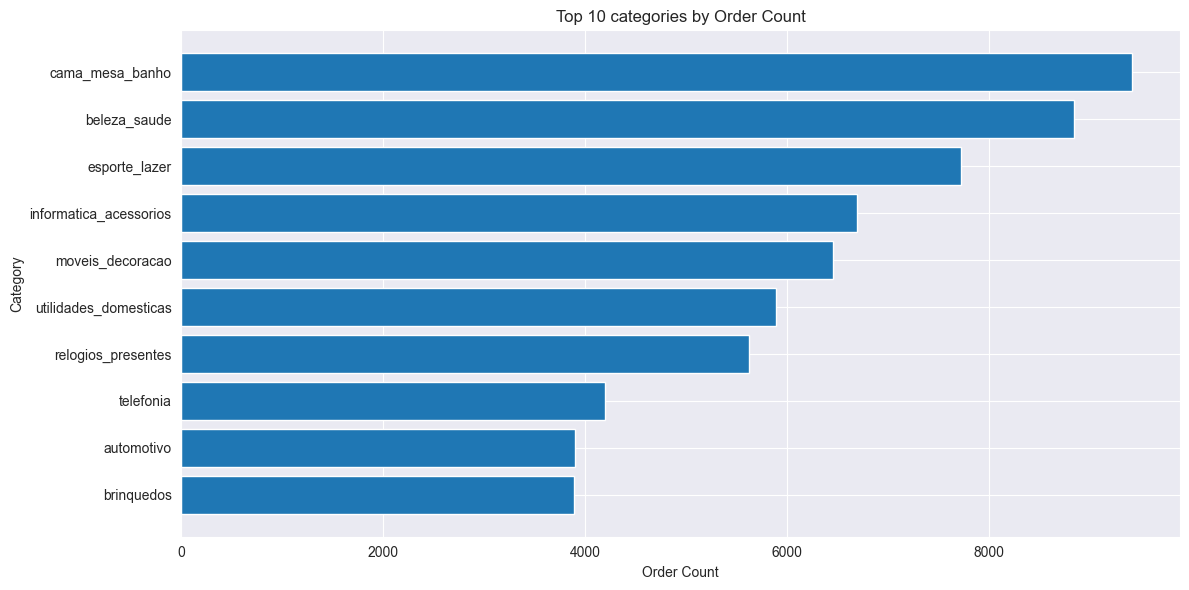

In [22]:
# visualise top 10 categories by order count

plt.figure(figsize=(12, 6))
plt.barh(top10_orders["category"], top10_orders["order_count"])
plt.xlabel("Order Count")
plt.ylabel("Category")
plt.title("Top 10 categories by Order Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
# add order share for easier interpretation

top10_orders = top10_orders.copy()
top10_orders["order_share_pct"] = (
    top10_orders["order_count"] / df_category["order_count"].sum() * 100
)

display(top10_orders)

,category,order_count,total_revenue,avg_review_score,order_share_pct
13,cama_mesa_banho,9417,1045462.93,3.9022,9.607321
11,beleza_saude,8836,1261034.70,4.1422,9.014579
32,esporte_lazer,7720,991175.20,4.1087,7.876024
44,informatica_acessorios,6689,916137.43,3.9364,6.824187
54,moveis_decoracao,6449,733077.86,3.9114,6.579337
72,utilidades_domesticas,5884,632981.59,4.0562,6.002918
66,relogios_presentes,5624,1206047.43,4.0192,5.737663
70,telefonia,4199,323735.40,3.9472,4.283863
8,automotivo,3897,593227.66,4.0650,3.975760
12,brinquedos,3886,484090.30,4.1617,3.964537


### 3.2 Top 10 Categories by Order Count Analysis
The order-count ranking highlights the categories with the broadest and most frequent customer demand. **cama_mesa_banho** ranks first with **9,417 orders**, followed by **beleza_saude** with **8,836 orders** and **esporte_lazer** with **7,720 orders**. These categories can be seen as major traffic-driving groups on the platform.

There is strong overlap between the top categories by revenue and by order count, which indicates that the platform’s core commercial categories are also its most frequently purchased ones. At the same time, some categories show a difference between revenue rank and order-volume rank. For example, **relogios_presentes** generates very high revenue with fewer orders than **cama_mesa_banho** or **beleza_saude**, suggesting a stronger contribution from higher average product value. In contrast, categories such as **telefonia** and **brinquedos** enter the top 10 by order volume but not by revenue, which may indicate relatively lower average transaction value.

### 3.3 Top 10 Categories by Satisfaction
Average review score is used to evaluate category-level customer satisfaction. However, categories with very few orders may show unstable average scores due to limited observations. Therefore, a minimum order threshold is applied before ranking categories by satisfaction, so that the comparison is more reliable and meaningful.

In [27]:
### 3.3 Top 10 Categories with enough order volume
min_orders = 100

df_satisfaction_rank = df_category[df_category["order_count"] >= min_orders].copy()

top10_satisfaction = (
    df_satisfaction_rank[["category", "avg_review_score", "order_count", "total_revenue"]]
    .sort_values("avg_review_score", ascending=False)
    .head(10)
)

print(f"Top 10 categories by satisfaction (min {min_orders} orders)")
display(top10_satisfaction)

Top 10 categories by satisfaction (min 100 orders)


,category,avg_review_score,order_count,total_revenue
48,livros_interesse_geral,4.4453,512,46856.88
49,livros_tecnicos,4.3684,260,19149.03
50,malas_acessorios,4.3153,1034,140429.98
2,alimentos_bebidas,4.3091,227,15218.47
34,fashion_calcados,4.2374,240,23592.67
1,alimentos,4.2134,450,29393.41
59,papelaria,4.1959,2311,231139.23
63,pet_shop,4.1841,1710,214443.41
61,pcs,4.1750,181,222963.13
28,eletrodomesticos,4.1700,764,82349.27


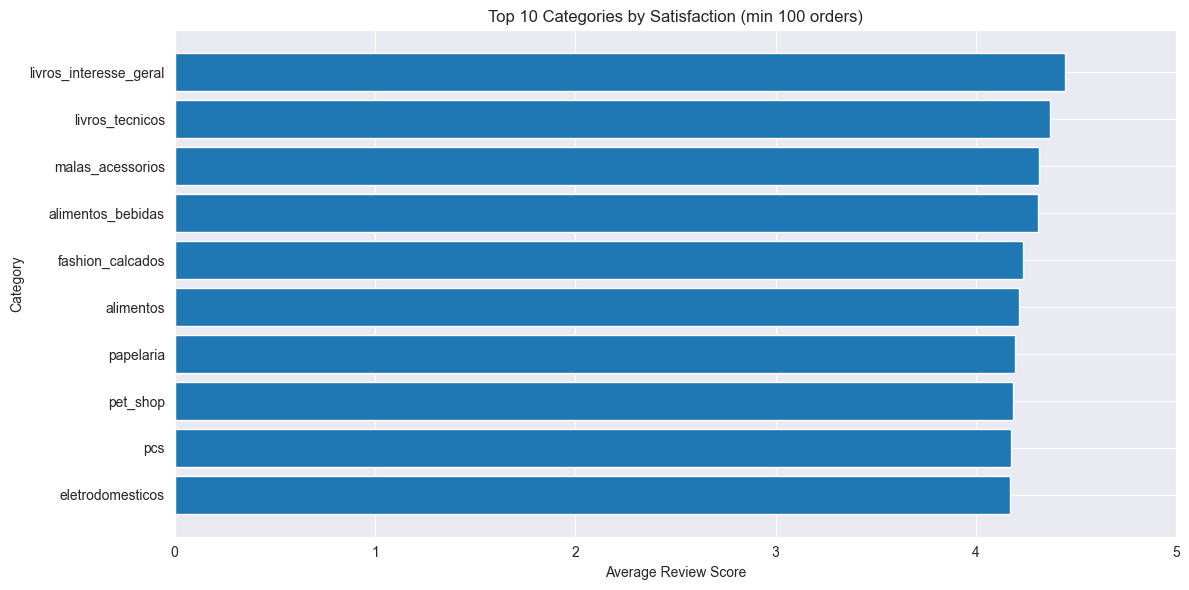

In [28]:
# visualise top 10 categories by satisfaction

plt.figure(figsize=(12, 6))
plt.barh(top10_satisfaction["category"], top10_satisfaction["avg_review_score"])
plt.xlabel("Average Review Score")
plt.ylabel("Category")
plt.title(f"Top 10 Categories by Satisfaction (min {min_orders} orders)")
plt.xlim(0, 5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Top 10 Categories by Satisfaction Analysis

The satisfaction ranking shows that the highest-rated categories are not necessarily the largest revenue contributors. **livros_interesse_geral** ranks first with an average review score of **4.4453**, followed by **livros_tecnicos** at **4.3684** and **malas_acessorios** at **4.3153**. These categories perform strongly in customer evaluation, suggesting that they provide a relatively positive purchase experience.

However, most of the top satisfaction categories have only moderate or relatively low order volumes and revenue compared with the platform’s leading commercial categories. For example, although **pcs** has a high average score, its order volume is only **181**, while categories such as **papelaria** and **pet_shop** combine stronger customer satisfaction with broader market demand. This suggests that high satisfaction alone does not automatically translate into large-scale commercial performance. Therefore, these categories may represent well-performing but under-scaled opportunities that deserve further attention in later strategy analysis.

### 3.4 Categories with Highest Bad Review Rate
Bad review rate reflects the proportion of strongly negative customer feedback within each category. Compared with average review score, this metric is more sensitive to dissatisfaction risk and can help identify-categories that may require operational improvement. Tp reduce instability caused by very small sample sizes, the same minimum order threshold is used here.

In [29]:
# rank categories by bad review rate
top10_bad_review = (
    df_satisfaction_rank[["category", "bad_review_rate", "avg_review_score", "order_count"]]
    .sort_values("bad_review_rate", ascending=False)
    .head(10)
)

print(f"Top 10 categories by bad review rate (min {min_orders} orders)")
display(top10_bad_review)

Top 10 categories by bad review rate (min 100 orders)


,category,bad_review_rate,avg_review_score,order_count
38,fashion_roupa_masculina,28.46154,3.6385,112
55,moveis_escritorio,25.92372,3.4988,1273
71,telefonia_fixa,25.57252,3.6832,217
7,audio,21.66667,3.8333,350
14,casa_conforto,20.32333,3.8291,397
25,construcao_ferramentas_seguranca,20.20725,3.8446,167
54,moveis_decoracao,19.30403,3.9114,6449
13,cama_mesa_banho,18.75570,3.9022,9417
44,informatica_acessorios,18.44209,3.9364,6689
57,moveis_sala,18.34677,3.8931,422


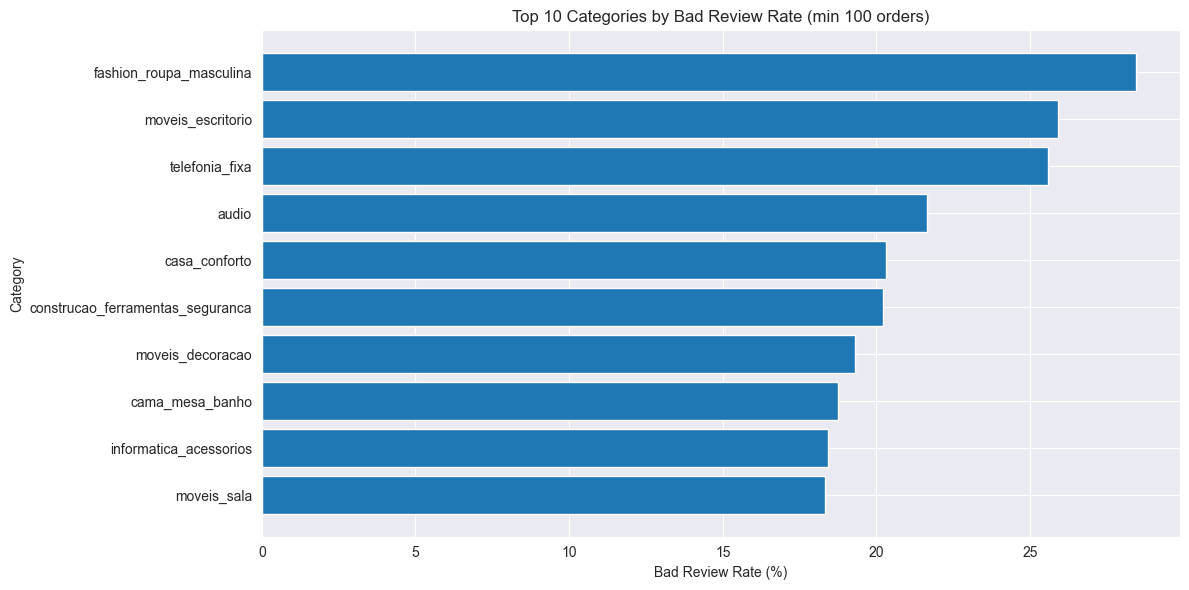

In [30]:
# visualise categories with highest bad review rate

plt.figure(figsize=(12, 6))
plt.barh(top10_bad_review["category"], top10_bad_review["bad_review_rate"])
plt.xlabel("Bad Review Rate (%)")
plt.ylabel("Category")
plt.title(f"Top 10 Categories by Bad Review Rate (min {min_orders} orders)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Categories with Highest Bad Review Rate Analysis
The bad review rate ranking highlights the categories with the greatest dissatisfaction risk. `fashion_roupa_masculina` ranks first, with a bad review rate of **28.46%**, followed by `moveis_escritorio` at **25.92%** and `telefonia_fixa` at **25.57%**. These categories show a relatively high concentration of strongly negative feedback and may require closer operational attention.

Compared with the satisfaction ranking above, the bad review ranking provides a more risk-focused perspective. Some categories with high bad review rates, such as `moveis_decoracao`, `cama_mesa_banho`, and `informatica_acessorios`, also have very large order volumes. This is particularly important because dissatisfaction in these categories affects not only customer experience but also a substantial share of platform transactions. Therefore, these categories should be treated as priority areas for further investigation, especially in terms of product quality, delivery performance, and expectation management.

### 3.5 Pareto Analysis of Category Revenue

To further evaluate category revenue concentration, Pareto analysis is applied to examine how much of the total revenue is contributed by the leading categories. This helps identify the core categories that account for most of the platform’s revenue and provides support for category prioritisation and inventory planning.

In [31]:
# prepare pareto analysis table
df_pareto = df_category[["category", "total_revenue"]].copy()
df_pareto = df_pareto.sort_values("total_revenue", ascending=False)

df_pareto["cumulative_revenue"] = df_pareto["total_revenue"].cumsum()
df_pareto["cumulative_pct"] = (
    df_pareto["cumulative_revenue"] / df_pareto["total_revenue"].sum() * 100
)

display(df_pareto.head(15))

,category,total_revenue,cumulative_revenue,cumulative_pct
11,beleza_saude,1261034.70,1261034.70,9.378399
66,relogios_presentes,1206047.43,2467082.13,18.347855
13,cama_mesa_banho,1045462.93,3512545.06,26.123032
32,esporte_lazer,991175.20,4503720.26,33.494469
44,informatica_acessorios,916137.43,5419857.69,40.307844
54,moveis_decoracao,733077.86,6152935.55,45.759793
26,cool_stuff,636254.61,6789190.16,50.491661
72,utilidades_domesticas,632981.59,7422171.75,55.199187
8,automotivo,593227.66,8015399.41,59.611061
40,ferramentas_jardim,486400.55,8501799.96,63.228455


In [32]:
# identify core categories contributing to about 80% of revenue
core_categories = df_pareto[df_pareto["cumulative_pct"] <= 80].copy()

print("Number of core categories contributing around 80% revenue:")
print(core_categories.shape[0])

display(core_categories)

Number of core categories contributing around 80% revenue:
16


,category,total_revenue,cumulative_revenue,cumulative_pct
11,beleza_saude,1261034.70,1261034.70,9.378399
66,relogios_presentes,1206047.43,2467082.13,18.347855
13,cama_mesa_banho,1045462.93,3512545.06,26.123032
32,esporte_lazer,991175.20,4503720.26,33.494469
44,informatica_acessorios,916137.43,5419857.69,40.307844
54,moveis_decoracao,733077.86,6152935.55,45.759793
26,cool_stuff,636254.61,6789190.16,50.491661
72,utilidades_domesticas,632981.59,7422171.75,55.199187
8,automotivo,593227.66,8015399.41,59.611061
40,ferramentas_jardim,486400.55,8501799.96,63.228455


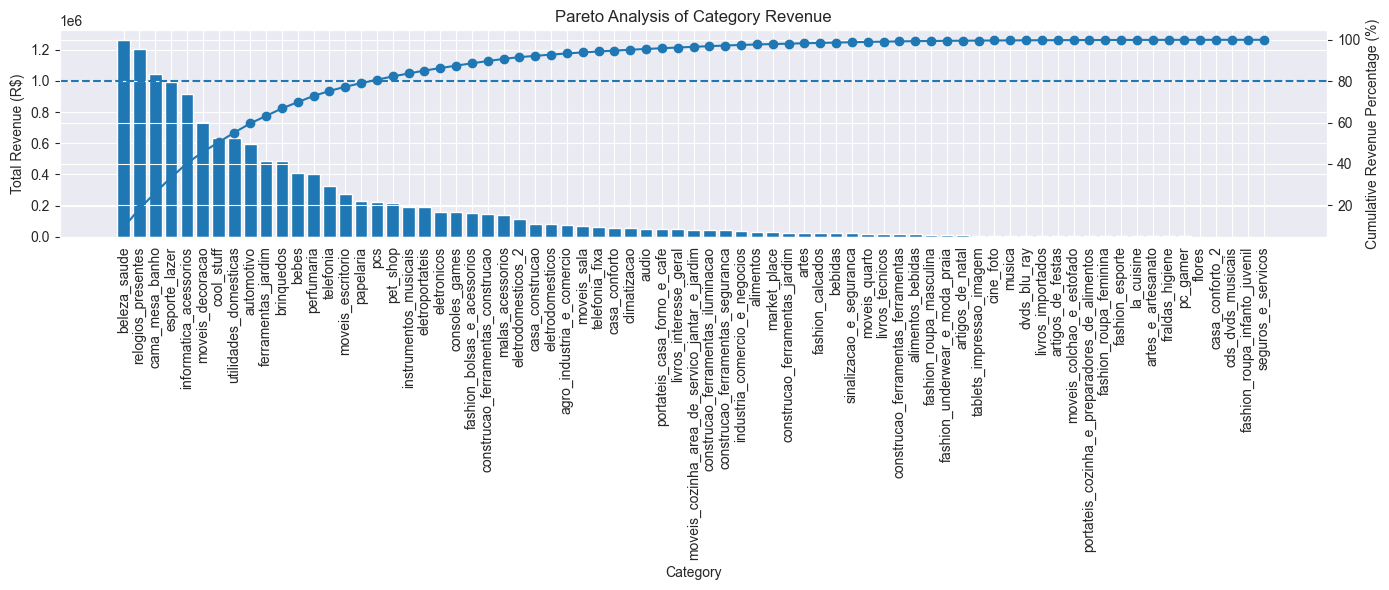

In [33]:
# pareto chart
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(df_pareto["category"], df_pareto["total_revenue"])
ax1.set_xlabel("Category")
ax1.set_ylabel("Total Revenue (R$)")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()
ax2.plot(df_pareto["category"], df_pareto["cumulative_pct"], marker="o")
ax2.axhline(80, linestyle="--")
ax2.set_ylabel("Cumulative Revenue Percentage (%)")

plt.title("Pareto Analysis of Category Revenue")
plt.tight_layout()
plt.show()

### Pareto Analysis of Category Revenue Analysis
The Pareto analysis shows that category revenue is highly concentrated. A total of **16 categories** account for around **80%** of the platform’s total revenue, which means that only a relatively small share of categories contributes most of the commercial value. This confirms that the platform has a strong revenue concentration structure rather than an evenly distributed category portfolio.

The core revenue categories include `beleza_saude`, `relogios_presentes`, `cama_mesa_banho`, `esporte_lazer`, and `informatica_acessorios`, all of which make substantial cumulative contributions to total revenue. As the cumulative curve rises quickly in the early part of the chart and then gradually flattens, it becomes clear that the platform depends heavily on a limited set of leading categories. From a business perspective, these core categories should be treated as strategic priorities in category management, inventory allocation, and promotional planning.

## 4. BCG Matrix Analysis

After comparing category performance from multiple ranking perspectives, the next step is to move from descriptive comparison to strategic classification. In this section, a BCG-style matrix is used to group categories based on their commercial value and customer satisfaction. This helps distinguish high-performing categories from risky or underdeveloped ones and provides a clearer basis for later business recommendations.

### 4.1 Defining the BCG Matrix Framework

To move from simple ranking analysis to strategic category classification, a BCG-style matrix is introduced. In this project, **total revenue** is used to represent category business scale, while **average review score** is used to reflect customer satisfaction and growth potential. By combining these two dimensions, categories can be grouped into four strategic types: high-revenue and high-satisfaction categories, high-revenue but low-satisfaction categories, low-revenue but high-satisfaction categories, and low-revenue and low-satisfaction categories.

To make the classification simple and interpretable, the median values of `total_revenue` and `avg_review_score` are used as the dividing lines. This allows each category to be assigned into one of four groups for later business interpretation.

In [34]:
# calculate median thresholds for BCG-style classification

median_revenue = df_category["total_revenue"].median()
median_score = df_category["avg_review_score"].median()

print(f"Median total revenue: {median_revenue:.2f}")
print(f"Median average review score: {median_score:.4f}")

Median total revenue: 46328.37
Median average review score: 4.0562


In [35]:
# classify categories into four BCG-style groups

def classify_bcg_category(row):
    if row["total_revenue"] >= median_revenue and row["avg_review_score"] >= median_score:
        return "Star"
    elif row["total_revenue"] >= median_revenue and row["avg_review_score"] < median_score:
        return "Problem"
    elif row["total_revenue"] < median_revenue and row["avg_review_score"] >= median_score:
        return "Opportunity"
    else:
        return "Dog"

df_category["bcg_category"] = df_category.apply(classify_bcg_category, axis=1)

print("BCG category counts:")
display(df_category["bcg_category"].value_counts())

BCG category counts:


bcg_category
Star           19
Problem        18
Opportunity    18
Dog            18
Name: count, dtype: int64

### Analysis
The median thresholds used for the BCG-style classification are **R$46,328.37** for `total_revenue` and **4.0562** for `avg_review_score`. These two values provide a simple and interpretable benchmark for separating categories into above-median and below-median groups in terms of both commercial scale and customer satisfaction.

The classification results are highly balanced, with **19** categories assigned to `Star` and **18** categories each assigned to `Problem`, `Opportunity`, and `Dog`. This balanced distribution is expected because median values are used as the dividing lines. It also suggests that the category portfolio can be meaningfully separated into four strategic groups, which provides a useful foundation for the visual matrix analysis in the next section.

### 4.2 BCG Matrix Visualisation

After defining the four BCG-style groups, the next step is to visualise the category portfolio in a two-dimensional matrix. In this chart, `total_revenue` is plotted on the horizontal axis and `avg_review_score` on the vertical axis. The size of each point represents `order_count`, which allows the matrix to reflect not only category position but also transaction scale.

The vertical and horizontal reference lines are set at the median values of `total_revenue` and `avg_review_score`, dividing the chart into four quadrants. This makes it easier to identify which categories belong to `Star`, `Problem`, `Opportunity`, and `Dog`, and to compare their relative scale and satisfaction performance.

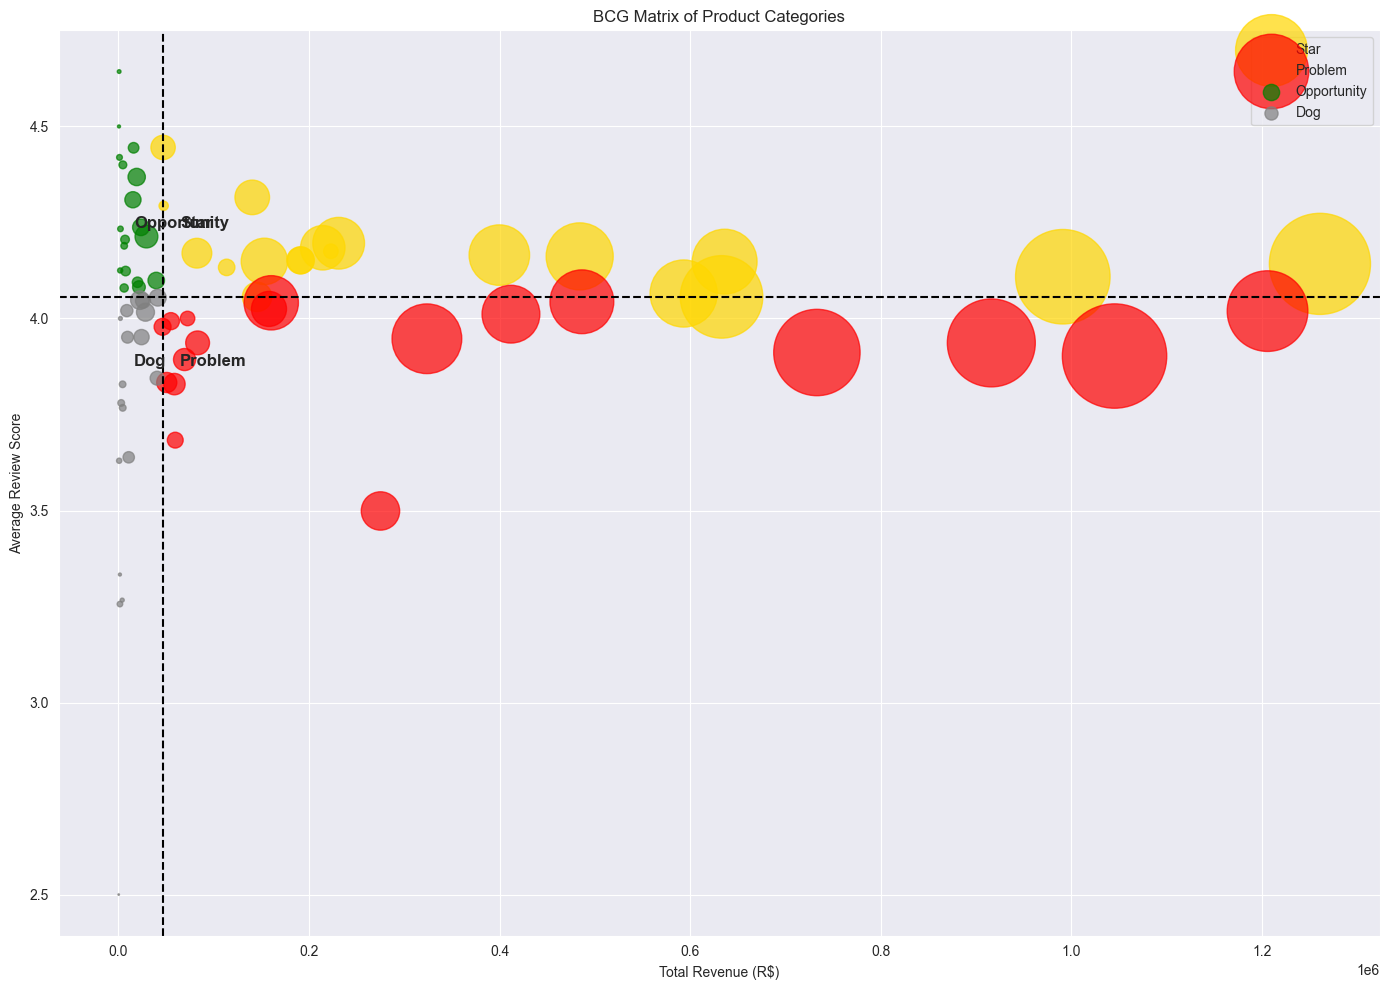

In [36]:
# visualise categories in a BCG-style matrix

plt.figure(figsize=(14, 10))

colors = {
    "Star": "gold",
    "Problem": "red",
    "Opportunity": "green",
    "Dog": "gray"
}

for group, color in colors.items():
    subset = df_category[df_category["bcg_category"] == group]
    plt.scatter(
        subset["total_revenue"],
        subset["avg_review_score"],
        s=subset["order_count"] * 0.6,
        alpha=0.7,
        label=group,
        c=color
    )

# add median reference lines
plt.axvline(median_revenue, color="black", linestyle="--", linewidth=1.5)
plt.axhline(median_score, color="black", linestyle="--", linewidth=1.5)

# axis labels and title
plt.xlabel("Total Revenue (R$)")
plt.ylabel("Average Review Score")
plt.title("BCG Matrix of Product Categories")

# optional quadrant labels
plt.text(median_revenue * 1.4, median_score + 0.18, "Star", fontsize=12, weight="bold")
plt.text(median_revenue * 1.4, median_score - 0.18, "Problem", fontsize=12, weight="bold")
plt.text(median_revenue * 0.35, median_score + 0.18, "Opportunity", fontsize=12, weight="bold")
plt.text(median_revenue * 0.35, median_score - 0.18, "Dog", fontsize=12, weight="bold")

plt.legend()
plt.tight_layout()
plt.show()

### BCG Matrix Visualisation Analysis

The BCG matrix shows a clear separation between commercially strong categories and smaller long-tail categories. Most of the large bubbles are concentrated on the right-hand side of the chart, indicating that a relatively small number of categories account for a substantial share of total revenue. At the same time, these high-revenue categories are split across both the upper-right and lower-right quadrants, which suggests that strong commercial performance does not always come with equally strong customer satisfaction.

Several important categories, such as `beleza_saude`, `esporte_lazer`, `cool_stuff`, and `automotivo`, appear in the `Star` quadrant, meaning that they combine above-median revenue with above-median review scores. These categories can be regarded as the strongest parts of the current category portfolio. In contrast, categories such as `cama_mesa_banho`, `moveis_decoracao`, and `informatica_acessorios` fall into the `Problem` quadrant, showing that some of the platform’s major revenue contributors still face below-median satisfaction performance. This makes them strategically important but also operationally risky.

On the left-hand side of the matrix, the `Opportunity` and `Dog` categories are generally much smaller in scale. `Opportunity` categories show relatively good customer satisfaction but limited revenue contribution, suggesting potential for further development. By contrast, `Dog` categories remain weak in both revenue and satisfaction, which means they are less likely to be priority areas unless they have special strategic value.

### 4.3 Category Details by BCG Group

After classifying categories into four BCG-style groups, the next step is to examine the specific categories within each group. This helps identify which categories are strong performers, risky core categories, potential growth categories, and weak categories.

In [37]:
# view category details by BCG group

star_categories = (
    df_category[df_category["bcg_category"] == "Star"]
    [["category", "total_revenue", "avg_review_score", "order_count", "bad_review_rate"]]
    .sort_values("total_revenue", ascending=False)
)

problem_categories = (
    df_category[df_category["bcg_category"] == "Problem"]
    [["category", "total_revenue", "avg_review_score", "order_count", "bad_review_rate"]]
    .sort_values("total_revenue", ascending=False)
)

opportunity_categories = (
    df_category[df_category["bcg_category"] == "Opportunity"]
    [["category", "total_revenue", "avg_review_score", "order_count", "bad_review_rate"]]
    .sort_values("avg_review_score", ascending=False)
)

dog_categories = (
    df_category[df_category["bcg_category"] == "Dog"]
    [["category", "total_revenue", "avg_review_score", "order_count", "bad_review_rate"]]
    .sort_values("total_revenue", ascending=False)
)

In [38]:
print("Star categories:")
display(star_categories.head(10))

print("Problem categories:")
display(problem_categories.head(10))

print("Opportunity categories:")
display(opportunity_categories.head(10))

print("Dog categories:")
display(dog_categories.head(10))

Star categories:


,category,total_revenue,avg_review_score,order_count,bad_review_rate
11,beleza_saude,1261034.70,4.1422,8836,13.71381
32,esporte_lazer,991175.20,4.1087,7720,14.55778
26,cool_stuff,636254.61,4.1480,3632,13.07120
72,utilidades_domesticas,632981.59,4.0562,5884,15.61731
8,automotivo,593227.66,4.0650,3897,15.24128
12,brinquedos,484090.30,4.1617,3886,13.44311
62,perfumaria,399772.51,4.1650,3162,14.50382
59,papelaria,231139.23,4.1959,2311,13.02083
61,pcs,222963.13,4.1750,181,13.00000
63,pet_shop,214443.41,4.1841,1710,12.97828


Problem categories:


,category,total_revenue,avg_review_score,order_count,bad_review_rate
66,relogios_presentes,1206047.43,4.0192,5624,16.25126
13,cama_mesa_banho,1045462.93,3.9022,9417,18.75570
44,informatica_acessorios,916137.43,3.9364,6689,18.44209
54,moveis_decoracao,733077.86,3.9114,6449,19.30403
40,ferramentas_jardim,486400.55,4.0435,3518,16.05281
9,bebes,411942.58,4.0112,2885,16.74893
70,telefonia,323735.40,3.9472,4199,16.82927
55,moveis_escritorio,275014.50,3.4988,1273,25.92372
30,eletronicos,160376.64,4.0408,2550,15.67055
20,consoles_games,158000.22,4.0249,1062,15.30249


Opportunity categories:


,category,total_revenue,avg_review_score,order_count,bad_review_rate
17,cds_dvds_musicais,730.00,4.6429,12,0.00000
37,fashion_roupa_infanto_juvenil,569.85,4.5000,8,12.50000
22,construcao_ferramentas_ferramentas,15903.95,4.4444,97,8.08081
41,flores,1110.04,4.4194,29,6.45161
47,livros_importados,4639.85,4.4000,53,11.66667
49,livros_tecnicos,19149.03,4.3684,260,10.90226
2,alimentos_bebidas,15218.47,4.3091,227,8.00000
34,fashion_calcados,23592.67,4.2374,240,12.06226
35,fashion_esporte,2119.51,4.2333,27,10.00000
1,alimentos,29393.41,4.2134,450,13.00813


Dog categories:


,category,total_revenue,avg_review_score,order_count,bad_review_rate
23,construcao_ferramentas_iluminacao,41308.00,4.0541,244,14.52703
25,construcao_ferramentas_seguranca,40544.52,3.8446,167,20.20725
51,market_place,28378.47,4.0163,280,14.33225
24,construcao_ferramentas_jardim,25740.29,4.0462,194,17.64706
3,artes,24202.64,3.9515,202,17.96117
10,bebidas,22505.90,4.0477,297,14.58886
38,fashion_roupa_masculina,10797.82,3.6385,112,28.46154
39,fashion_underwear_e_moda_praia,9541.55,3.9512,121,17.88618
6,artigos_de_natal,8800.82,4.0205,128,14.38356
5,artigos_de_festas,4485.18,3.7674,39,23.25581


### Category Details by BCG Group Analysis
The `Star` group contains the platform’s strongest categories, including `beleza_saude`, `esporte_lazer`, `cool_stuff`, and `automotivo`, which combine high revenue with above-median satisfaction. These categories represent the most balanced and commercially attractive part of the category portfolio.

The `Problem` group includes several major revenue drivers, such as `relogios_presentes`, `cama_mesa_banho`, `informatica_acessorios`, and `moveis_decoracao`, but their review scores remain below the median. This suggests that some core categories generate strong sales while still facing noticeable customer experience risk.

The `Opportunity` group shows relatively high satisfaction but limited revenue contribution. Categories such as `livros_tecnicos`, `alimentos_bebidas`, `fashion_calcados`, and `alimentos` may have growth potential, although some very small categories in this group should be interpreted with caution due to limited order volume. By contrast, the `Dog` group remains weak in both revenue and satisfaction, with categories such as `fashion_roupa_masculina` and `artigos_de_festas` showing relatively limited business strength.

## 5. Customer Preference Analysis by RFM Segment

After classifying product categories by overall performance, the next step is to examine customer preference differences across user segments. By linking category purchases with RFM groups, this section explores whether different customer types show different category preferences and spending patterns.

### 5.1 Loading RFM Segmentation Results

To analyse category preference by customer type, the RFM segmentation results from the previous project are introduced. These results allow the order-level category data to be connected with user groups, providing a foundation for comparing category demand across different segments.

In [44]:
# load RFM segmentation result from the previous project

df_rfm = pd.read_csv("output/user_segments_rfm.csv")

print(df_rfm.shape)
df_rfm.head()

FileNotFoundError: [Errno 2] No such file or directory: 'output/user_segments_rfm.csv'

当前工作目录： C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\Statistical_analysis_report

当前目录下的文件和文件夹：
['01_satisfaction_vs_delivery.ipynb', '02.User_Segmentation_vs_ Value_Analysis_(RFM Model).ipynb', '03_product_category_analysis.ipynb', '04_geographic_analysis.ipynb', '05_time_series_analysis.ipynb']
